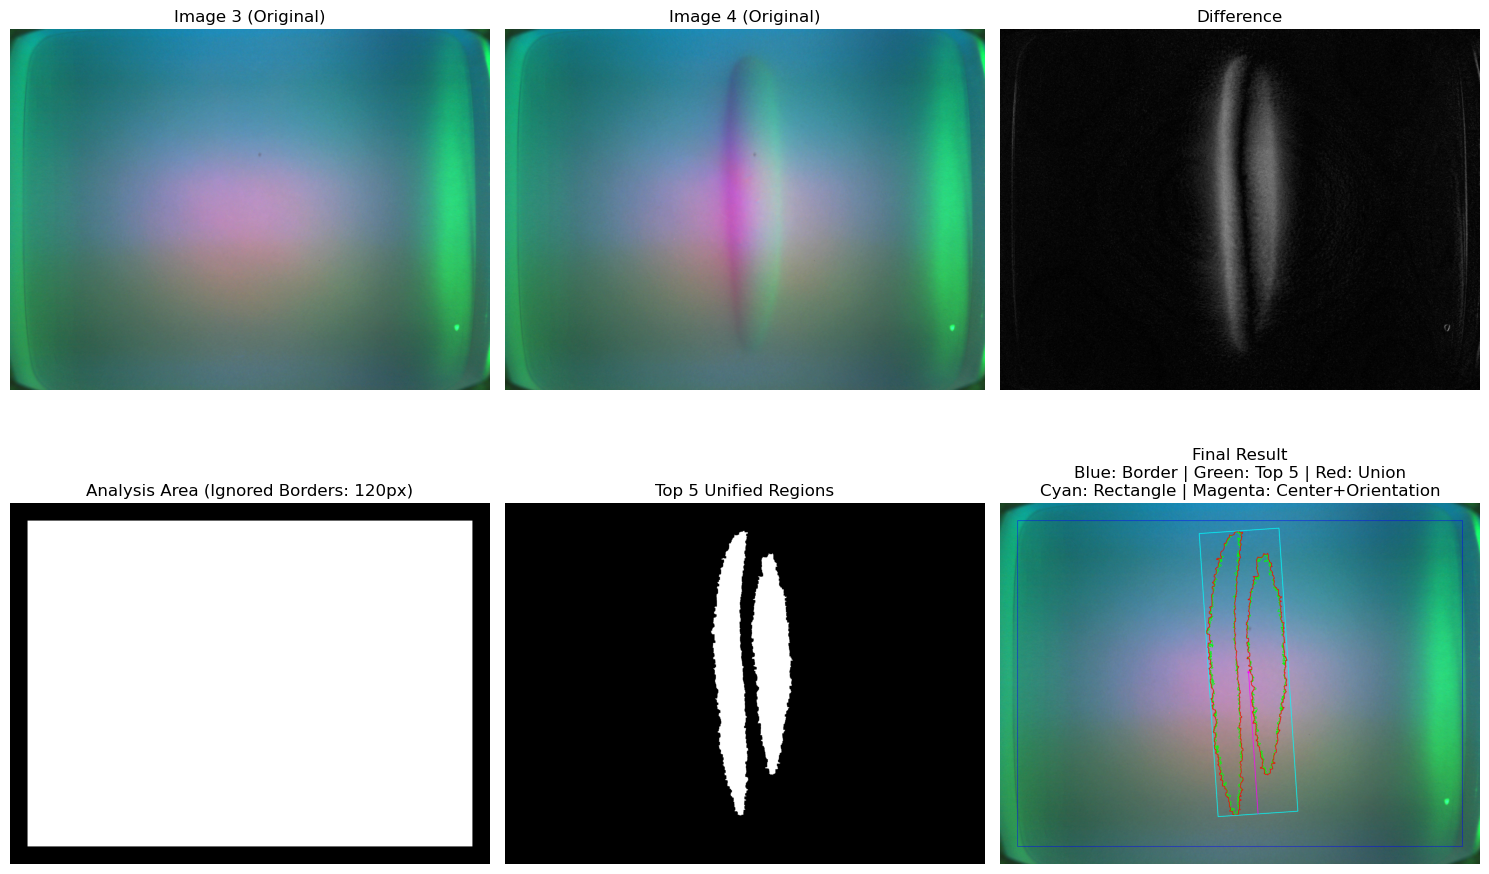

Ignored border area: 120 pixels
Total detected contours: 2
Top 5 largest regions selected
Area of the top 5 regions: 529146 pixels
Area of the unified region: 566788 pixels

--- Rectangle Analysis ---
Rectangle center: (1698.7, 1156.0) pixels
Dimensions: 1936.2 x 546.3 pixels
Rotation angle: 86.19 degrees

--- Center Displacement ---
Image center: (1640, 1232) pixels
X Displacement: 58.7 pixels
Y Displacement: -76.0 pixels
Distance from center: 96.0 pixels


In [4]:
import matplotlib
matplotlib.use('Agg')
import cv2
import numpy as np
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image

# Load the images
img3 = cv2.imread('src/tactile_cameras/examples/my_photo-3.jpg')
img4 = cv2.imread('src/tactile_cameras/examples/my_photo-4.jpg')

# Define border area to be ignored
border_size = 120  # Border size in pixels to be ignored

# Convert to grayscale
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

# Calculate the absolute difference between the images
diff = cv2.absdiff(gray3, gray4)

# Apply threshold to highlight significant differences
_, thresh = cv2.threshold(diff, 10, 255, cv2.THRESH_BINARY)

# Create mask to ignore border area
h, w = thresh.shape
border_mask = np.zeros((h, w), dtype=np.uint8)
border_mask[border_size:h-border_size, border_size:w-border_size] = 255

# Apply border mask to the threshold
thresh = cv2.bitwise_and(thresh, border_mask)

# Find contours of the contact area
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours by minimum area
valid_contours = [c for c in contours if cv2.contourArea(c) > 500]

# Select the top 5 largest regions
valid_contours_sorted = sorted(valid_contours, key=cv2.contourArea, reverse=True)
top_5_contours = valid_contours_sorted[:5]

# Create a mask to unite the 5 largest regions
unified_mask = np.zeros_like(thresh)
for contour in top_5_contours:
    cv2.drawContours(unified_mask, [contour], -1, 255, -1)

# Apply morphological operation to unite close regions
kernel_large = np.ones((15,15), np.uint8)
unified_mask = cv2.morphologyEx(unified_mask, cv2.MORPH_CLOSE, kernel_large)

# Find the contour of the unified region
unified_contours, _ = cv2.findContours(unified_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create result image
result = img3.copy()

# Draw the ignored border area in blue
cv2.rectangle(result, (border_size, border_size), (w-border_size, h-border_size), (255, 0, 0), 2)

contact_area = 0

# Draw the 5 largest original regions in green
for contour in top_5_contours:
    cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)
    contact_area += cv2.contourArea(contour)

# Draw the unified contour in red
if len(unified_contours) > 0:
    cv2.drawContours(result, unified_contours, -1, (0, 0, 255), 3)
    unified_area = sum([cv2.contourArea(c) for c in unified_contours])
    
    all_points = np.vstack(unified_contours)
    rect = cv2.minAreaRect(all_points)
    box = cv2.boxPoints(rect)
    box = box.astype(int)
    
    center, (width, height), angle = rect
    center_x, center_y = center
    
    cv2.drawContours(result, [box], 0, (255, 255, 0), 3)
    cv2.circle(result, (int(center_x), int(center_y)), 8, (255, 0, 255), -1)
    
    angle_rad = np.radians(angle)
    line_length = max(width, height) / 2
    end_x = int(center_x + line_length * np.cos(angle_rad))
    end_y = int(center_y + line_length * np.sin(angle_rad))
    cv2.line(result, (int(center_x), int(center_y)), (end_x, end_y), (255, 0, 255), 3)
    
    img_center_x, img_center_y = w // 2, h // 2
    offset_x = center_x - img_center_x
    offset_y = center_y - img_center_y
    distance_from_center = np.sqrt(offset_x**2 + offset_y**2)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Image 3 (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Image 4 (Original)')
axes[0, 1].axis('off')

axes[0, 2].imshow(diff, cmap='gray')
axes[0, 2].set_title('Difference')
axes[0, 2].axis('off')

axes[1, 0].imshow(border_mask, cmap='gray')
axes[1, 0].set_title(f'Analysis Area (Ignored Borders: {border_size}px)')
axes[1, 0].axis('off')

axes[1, 1].imshow(unified_mask, cmap='gray')
axes[1, 1].set_title('Top 5 Unified Regions')
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title(f'Final Result\nBlue: Border | Green: Top 5 | Red: Union\nCyan: Rectangle | Magenta: Center+Orientation')
axes[1, 2].axis('off')

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
display(Image(buf.read()))
plt.close()

print(f"Ignored border area: {border_size} pixels")
print(f"Total detected contours: {len(valid_contours)}")
print(f"Top 5 largest regions selected")
print(f"Area of the top 5 regions: {contact_area:.0f} pixels")
if len(unified_contours) > 0:
    print(f"Area of the unified region: {unified_area:.0f} pixels")
    print(f"\n--- Rectangle Analysis ---")
    print(f"Rectangle center: ({center_x:.1f}, {center_y:.1f}) pixels")
    print(f"Dimensions: {width:.1f} x {height:.1f} pixels")
    print(f"Rotation angle: {angle:.2f} degrees")
    print(f"\n--- Center Displacement ---")
    print(f"Image center: ({img_center_x}, {img_center_y}) pixels")
    print(f"X Displacement: {offset_x:.1f} pixels")
    print(f"Y Displacement: {offset_y:.1f} pixels")
    print(f"Distance from center: {distance_from_center:.1f} pixels")